# Predicting Customer Purchase Behaviour
**Assignment:** Develop a Machine Learning model for Predicting Customer Purchase Behaviour, deploy with Streamlit, and publish to GitHub.

**Dataset:** [Predict Customer Purchase Behavior Dataset](https://www.kaggle.com/datasets/rabieelkharoua/predict-customer-purchase-behavior-dataset) (Kaggle)

**Pipeline:** EDA → Feature Engineering → Preprocessing → Model Training → Evaluation → Deployment (Streamlit)


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, RocCurveDisplay)
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
RANDOM_STATE = 42

## 2. Load Data

In [2]:
df = pd.read_csv('data/customer_purchase_data.csv')
print(df.shape)
df.head()

(1500, 9)


,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
0,40,1,66120.267939,8,0,30.568601,0,5,1
1,20,1,23579.773583,4,2,38.240097,0,5,0
2,27,1,127821.306432,11,2,31.633212,1,0,1
3,24,1,137798.623120,19,3,46.167059,0,4,1
4,31,1,99300.964220,19,1,19.823592,0,0,1


## 3. Exploratory Data Analysis (EDA)

**Feature dictionary:**
- `Age` — customer age
- `Gender` — 0 = Female, 1 = Male
- `AnnualIncome` — customer's annual income (USD)
- `NumberOfPurchases` — total past purchases
- `ProductCategory` — 0: Electronics, 1: Clothing, 2: Home Goods, 3: Beauty, 4: Sports
- `TimeSpentOnWebsite` — minutes spent on site per session
- `LoyaltyProgram` — 0 = not enrolled, 1 = enrolled
- `DiscountsAvailed` — number of discounts used
- `PurchaseStatus` — **target**: 0 = did not purchase, 1 = purchased

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 1500 non-null   int64  
 1   Gender              1500 non-null   int64  
 2   AnnualIncome        1500 non-null   float64
 3   NumberOfPurchases   1500 non-null   int64  
 4   ProductCategory     1500 non-null   int64  
 5   TimeSpentOnWebsite  1500 non-null   float64
 6   LoyaltyProgram      1500 non-null   int64  
 7   DiscountsAvailed    1500 non-null   int64  
 8   PurchaseStatus      1500 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 105.6 KB


In [4]:
df.isnull().sum()

Age                   0
Gender                0
AnnualIncome          0
NumberOfPurchases     0
ProductCategory       0
TimeSpentOnWebsite    0
LoyaltyProgram        0
DiscountsAvailed      0
PurchaseStatus        0
dtype: int64

In [5]:
df.describe()

,Age,Gender,AnnualIncome,NumberOfPurchases,ProductCategory,TimeSpentOnWebsite,LoyaltyProgram,DiscountsAvailed,PurchaseStatus
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000
mean,44.298667,0.504667,84249.164338,10.420000,2.012667,30.469040,0.326667,2.555333,0.43200
std,15.537259,0.500145,37629.493078,5.887391,1.428005,16.984392,0.469151,1.705152,0.49552
min,18.000000,0.000000,20001.512518,0.000000,0.000000,1.037023,0.000000,0.000000,0.00000
25%,31.000000,0.000000,53028.979155,5.000000,1.000000,16.156700,0.000000,1.000000,0.00000
50%,45.000000,1.000000,83699.581476,11.000000,2.000000,30.939516,0.000000,3.000000,0.00000
75%,57.000000,1.000000,117167.772858,15.000000,3.000000,44.369863,1.000000,4.000000,1.00000
max,70.000000,1.000000,149785.176481,20.000000,4.000000,59.991105,1.000000,5.000000,1.00000


### 3.1 Target Distribution (Class Balance)

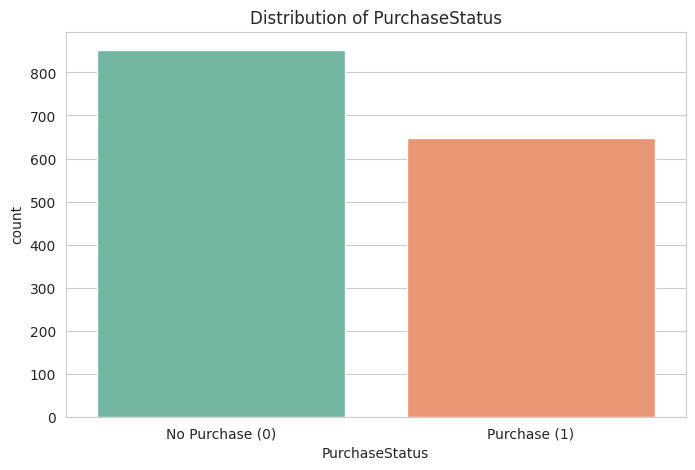

PurchaseStatus
0    56.8
1    43.2
Name: proportion, dtype: float64


In [6]:
ax = sns.countplot(x='PurchaseStatus', data=df, hue='PurchaseStatus', palette='Set2', legend=False)
ax.set_title('Distribution of PurchaseStatus')
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Purchase (0)', 'Purchase (1)'])
plt.savefig('outputs/target_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

print(df['PurchaseStatus'].value_counts(normalize=True).round(3) * 100)

### 3.2 Numeric Feature Distributions

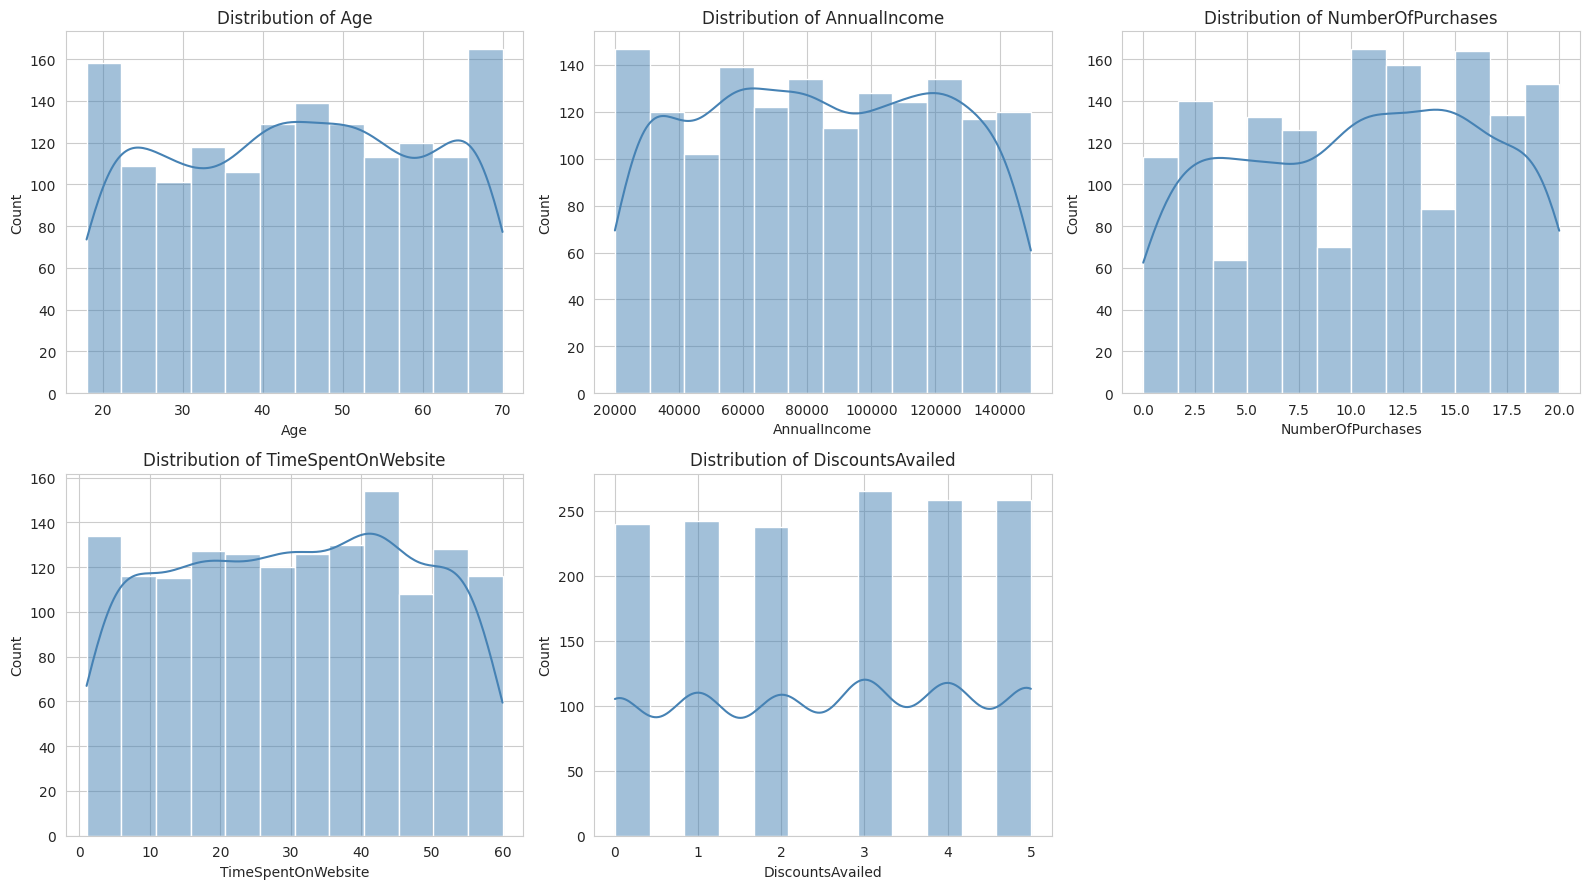

In [7]:
num_cols = ['Age', 'AnnualIncome', 'NumberOfPurchases', 'TimeSpentOnWebsite', 'DiscountsAvailed']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('outputs/numeric_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.3 Correlation with Target

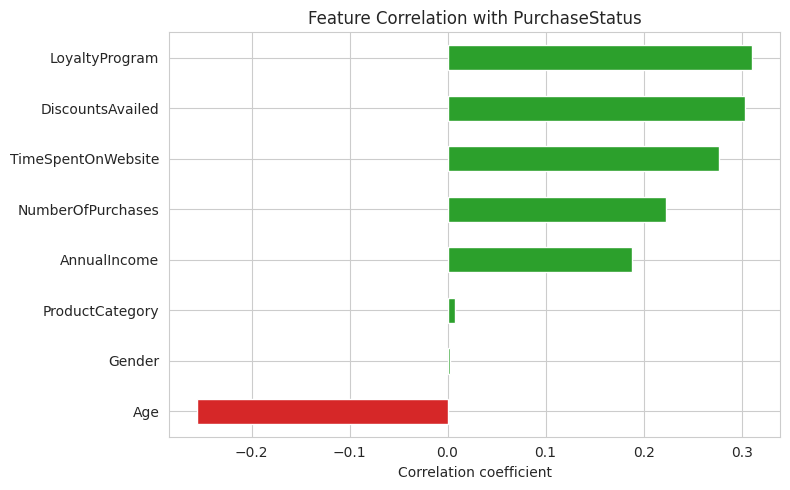

Age                  -0.255747
Gender                0.002627
ProductCategory       0.007346
AnnualIncome          0.188214
NumberOfPurchases     0.222691
TimeSpentOnWebsite    0.277112
DiscountsAvailed      0.303297
LoyaltyProgram        0.310838
Name: PurchaseStatus, dtype: float64

In [8]:
corr = df.corr(numeric_only=True)['PurchaseStatus'].drop('PurchaseStatus').sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
corr.plot(kind='barh', color=corr.apply(lambda x: '#2ca02c' if x > 0 else '#d62728'), ax=ax)
ax.set_title('Feature Correlation with PurchaseStatus')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.savefig('outputs/correlation_with_target.png', dpi=100, bbox_inches='tight')
plt.show()
corr

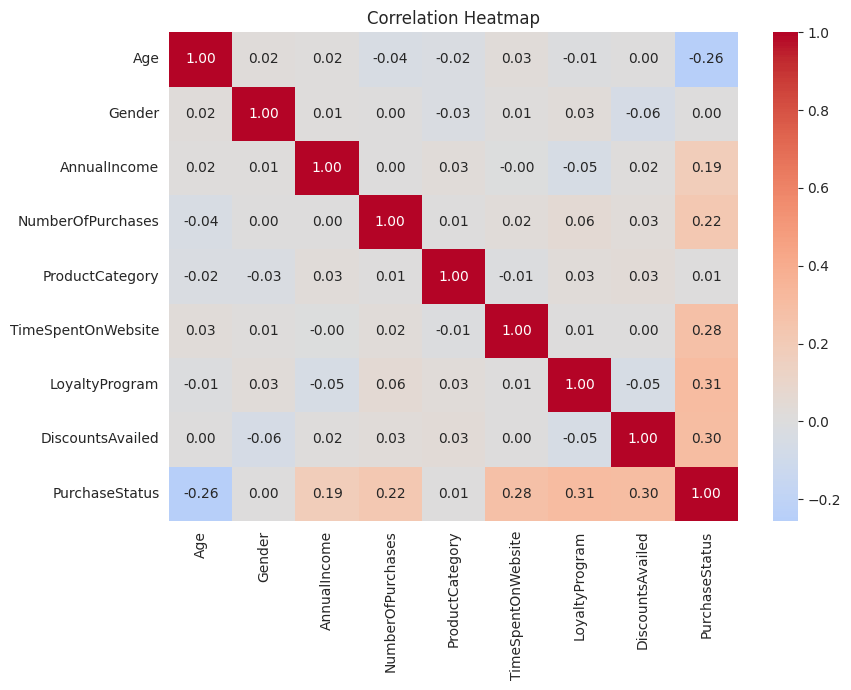

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('outputs/correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

### 3.4 Key Observations
- The target is mildly imbalanced (~57% no-purchase, ~43% purchase) — not severe enough to require resampling, but worth tracking precision/recall alongside accuracy.
- `LoyaltyProgram`, `DiscountsAvailed`, and `TimeSpentOnWebsite` show the strongest positive correlation with purchasing.
- `Age` shows a negative correlation — younger customers in this dataset are somewhat more likely to purchase.
- `Gender` and `ProductCategory` show close to zero correlation with the target on their own.

## 4. Feature Engineering & Preprocessing

In [10]:
FEATURES = ['Age', 'Gender', 'AnnualIncome', 'NumberOfPurchases', 'ProductCategory',
            'TimeSpentOnWebsite', 'LoyaltyProgram', 'DiscountsAvailed']
TARGET = 'PurchaseStatus'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train shape:', X_train.shape, ' Test shape:', X_test.shape)

Train shape: (1200, 8)  Test shape: (300, 8)


## 5. Model Training
We compare Logistic Regression (baseline, interpretable) against Random Forest (typically stronger on tabular data with feature interactions).

In [11]:
models = {
    'Logistic Regression': LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
}

results = {}
for name, model in models.items():
    # Logistic Regression benefits from scaled features; Random Forest doesn't need it
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'roc_auc': roc_auc_score(y_test, probs),
        'preds': preds,
        'probs': probs
    }

results_df = pd.DataFrame({k: {m: round(v, 4) for m, v in val.items() if isinstance(v, (int, float))}
                            for k, val in results.items()}).T
results_df

,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.8267,0.8250,0.7615,0.7920,0.8995
Random Forest,0.9267,0.9219,0.9077,0.9147,0.9400


### 5.1 Confusion Matrices

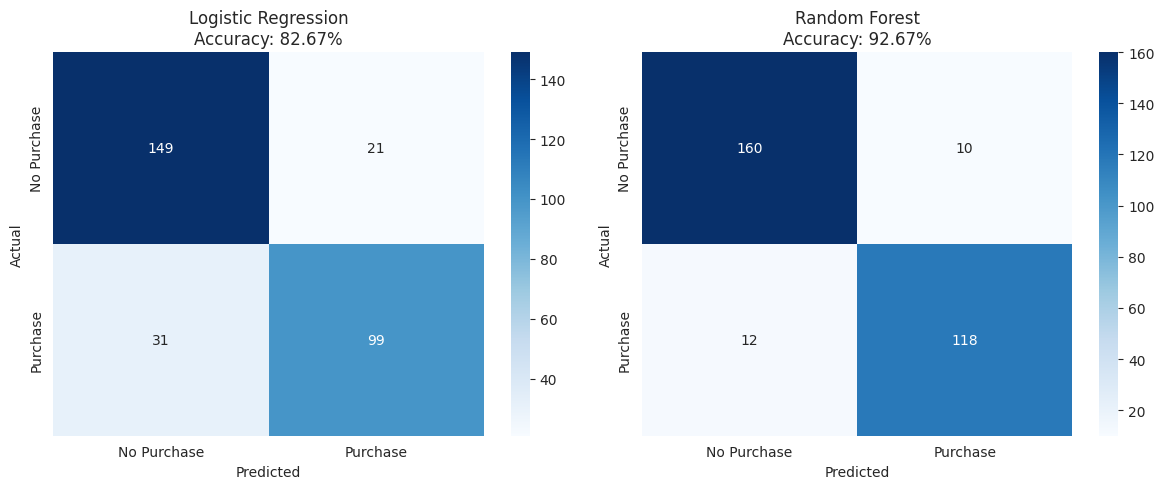

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Purchase', 'Purchase'],
                yticklabels=['No Purchase', 'Purchase'])
    ax.set_title(f'{name}\nAccuracy: {res["accuracy"]:.2%}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

### 5.2 ROC Curves

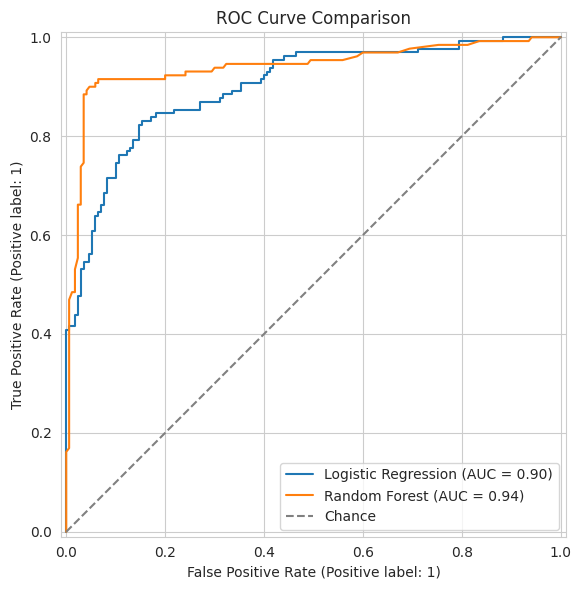

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, res in results.items():
    RocCurveDisplay.from_predictions(y_test, res['probs'], name=name, ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

### 5.3 Feature Importance (Random Forest)

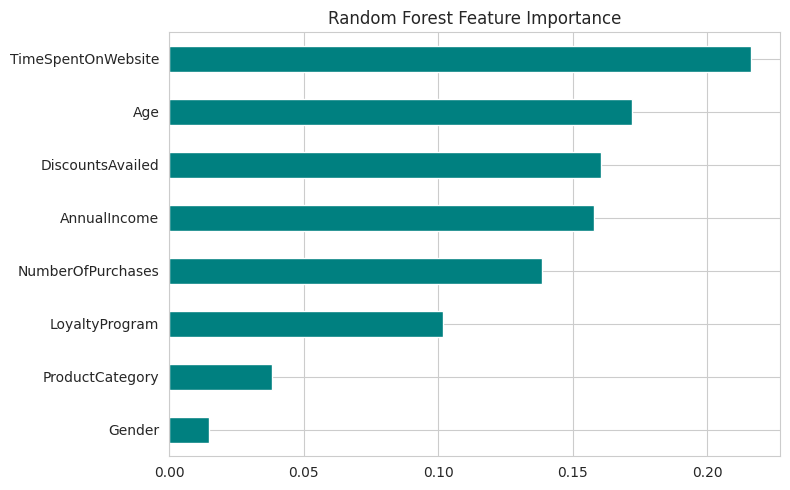

In [14]:
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', color='teal', ax=ax)
ax.set_title('Random Forest Feature Importance')
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Model Selection & Final Evaluation

In [15]:
best_name = results_df['f1'].idxmax()
print(f'Best model by F1-score: {best_name}')
print()
best_res = results[best_name]
print(classification_report(y_test, best_res['preds'], target_names=['No Purchase', 'Purchase']))

Best model by F1-score: Random Forest

              precision    recall  f1-score   support

 No Purchase       0.93      0.94      0.94       170
    Purchase       0.92      0.91      0.91       130

    accuracy                           0.93       300
   macro avg       0.93      0.92      0.93       300
weighted avg       0.93      0.93      0.93       300



## 7. Save Final Model
We persist the trained model (and scaler, if needed) so the Streamlit app doesn't retrain on every run.

In [16]:
import os
os.makedirs('models', exist_ok=True)

final_model = results['Random Forest']['model']  # Random Forest needs no scaling, simplifying deployment
joblib.dump(final_model, 'models/purchase_model.pkl')
joblib.dump(FEATURES, 'models/feature_names.pkl')

print('Model saved to models/purchase_model.pkl')

Model saved to models/purchase_model.pkl


## 8. Conclusion
- Both models perform well on this dataset; the Random Forest classifier was selected as the final model as it captures non-linear feature interactions without requiring feature scaling, simplifying the Streamlit deployment.
- `LoyaltyProgram`, `DiscountsAvailed`, `TimeSpentOnWebsite`, and `Age` are the strongest predictors of purchase behaviour.
- Next step: deploy `models/purchase_model.pkl` inside a Streamlit app (`app.py`) for interactive, real-time predictions.